# Auditing real U.S. market returns

This executed notebook applies `return-series-auditor` to genuine monthly U.S. market-factor data from the official Kenneth French Data Library. It reconstructs the broad market return as **Mkt-RF + RF**, converts percentages to decimal returns, and uses the package's public interface instead of reproducing its audit logic.

The goal is practical: verify the input's integrity, inspect long-horizon performance fragility, visualize growth and drawdown, and prove that controlled data corruption is detected.

In [1]:
import csv
import hashlib
import io
import re
import zipfile
from datetime import datetime, timezone
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from IPython.display import display

from return_series_auditor import audit_file

DATA_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_Factors_CSV.zip"
)
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository checkout.")
CHART_PATH = REPO_ROOT / "docs" / "assets" / "real-market-audit.png"
pd.options.display.max_colwidth = 120

## Download and provenance

The archive is downloaded directly from Dartmouth's official library during execution. The SHA-256 below hashes the downloaded ZIP bytes, making this run identifiable without committing the external dataset. The library can revise historical values, so later executions may have a different hash or observation range.

In [2]:
request = Request(
    DATA_URL,
    headers={
        "User-Agent": (
            "return-series-auditor/1.1.0 "
            "(+https://github.com/carlosbarredo/return-series-auditor)"
        )
    },
)
with urlopen(request, timeout=60) as response:
    archive_bytes = response.read()
retrieved_at_utc = datetime.now(timezone.utc).replace(microsecond=0).isoformat()
archive_sha256 = hashlib.sha256(archive_bytes).hexdigest()

with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
    csv_members = [name for name in archive.namelist() if name.lower().endswith(".csv")]
    if len(csv_members) != 1:
        raise ValueError(f"Expected one CSV in the archive, found {csv_members!r}.")
    source_member = csv_members[0]
    source_text = archive.read(source_member).decode("utf-8-sig")

monthly_rows = []
for row in csv.reader(io.StringIO(source_text)):
    if len(row) >= 5 and re.fullmatch(r"\d{6}", row[0].strip()):
        monthly_rows.append(
            {
                "period": row[0].strip(),
                "Mkt-RF": float(row[1]),
                "RF": float(row[4]),
            }
        )

factors = pd.DataFrame(monthly_rows)
if factors.empty or factors[["Mkt-RF", "RF"]].isna().any().any():
    raise ValueError("The monthly factor table is empty or contains missing values.")
dates = pd.to_datetime(factors["period"], format="%Y%m") + pd.offsets.MonthEnd(0)
market = pd.DataFrame(
    {
        "date": dates,
        "return": (factors["Mkt-RF"] + factors["RF"]) / 100.0,
    }
)
audit_input = market.assign(date=market["date"].dt.strftime("%Y-%m-%d"))

provenance = pd.DataFrame(
    {
        "Value": [
            DATA_URL,
            retrieved_at_utc,
            source_member,
            market["date"].iloc[0].date().isoformat(),
            market["date"].iloc[-1].date().isoformat(),
            f"{len(market):,}",
            archive_sha256,
        ]
    },
    index=[
        "Source URL",
        "Retrieved at (UTC)",
        "Archive member",
        "First observation",
        "Last observation",
        "Observations",
        "Downloaded ZIP SHA-256",
    ],
)
display(provenance)
print("Exact input shape expected by return-series-auditor:")
display(audit_input.head())

,Value
Source URL,https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip
Retrieved at (UTC),2026-08-09T17:57:12+00:00
Archive member,F-F_Research_Data_Factors.csv
First observation,1926-07-31
Last observation,2026-06-30
Observations,"1,200"
Downloaded ZIP SHA-256,cd6d8e0d175b6f423862a6ad15a3073a6e4264b52b2ac9262396c79f707c6bcb


Exact input shape expected by return-series-auditor:


,date,return
0,1926-07-31,0.0311
1,1926-08-31,0.0289
2,1926-09-30,0.0061
3,1926-10-31,-0.0295
4,1926-11-30,0.0285


## Run the installed auditor

The reconstructed two-column input is written only inside a temporary directory, then passed to the package's public `audit_file` interface. The external archive and complete parsed dataset are never saved in the repository.

In [3]:
with TemporaryDirectory(prefix="return-audit-") as temporary_directory:
    input_path = Path(temporary_directory) / "real_market_returns.csv"
    audit_input.to_csv(input_path, index=False)
    report = audit_file(input_path)

metrics = report.metrics
metric_table = pd.DataFrame(
    {
        "Value": [
            f"{metrics.observations:,}",
            metrics.inferred_frequency,
            f"{metrics.total_compounded_return:.2%}",
            f"{metrics.cagr:.2%}",
            f"{metrics.annualized_volatility:.2%}",
            f"{metrics.sharpe_ratio:.3f}",
            f"{metrics.sortino_ratio:.3f}",
            f"{metrics.maximum_drawdown:.2%}",
            f"{metrics.maximum_drawdown_duration:,} months",
            f"{metrics.current_drawdown:.2%}",
            "Yes" if metrics.maximum_drawdown_recovered else "No",
        ]
    },
    index=[
        "Observations",
        "Inferred frequency",
        "Total compounded return",
        "CAGR",
        "Annualized volatility",
        "Sharpe ratio (RF = 0)",
        "Sortino ratio",
        "Maximum drawdown",
        "Maximum drawdown duration",
        "Current drawdown",
        "Maximum drawdown recovered",
    ],
)
print(f"Audit result: {report.summary_status.value} (exit code {report.exit_code()})")
display(metric_table)
finding_table = pd.DataFrame(
    [
        {
            "Status": finding.status.value,
            "Check": finding.title,
            "Explanation": finding.explanation,
        }
        for finding in report.findings
    ]
)
display(finding_table)

Audit result: WARN (exit code 0)


,Value
Observations,"1,200"
Inferred frequency,monthly
Total compounded return,1922351.49%
CAGR,10.37%
Annualized volatility,18.34%
Sharpe ratio (RF = 0),0.631
Sortino ratio,0.986
Maximum drawdown,-83.65%
Maximum drawdown duration,184 months
Current drawdown,-0.78%


,Status,Check,Explanation
0,PASS,Missing values,No required values are missing.
1,PASS,Unparseable values,All non-missing dates and numeric values are parseable.
2,PASS,Non-finite numbers,All parsed numeric values are finite.
3,PASS,Duplicate dates,Every parsed date is unique.
4,PASS,Date order,Parsed dates are in chronological order.
5,PASS,Impossible returns,Every parsed return is greater than -100%.
6,PASS,Suspicious gaps,No gap exceeds 62 calendar days for inferred monthly data.
7,PASS,Track-record length,"The series contains 1200 usable returns, meeting the 12-period threshold."
8,PASS,Return variance,"Annualized volatility is 18.344364%, above the near-zero threshold."
9,PASS,Dependence on best 1 period,"Removing the best 1 period(s) changes compounded return from 1922351.49% to 1383854.71%, a 28.0% reduction relative ..."


## Growth and drawdown

A logarithmic axis keeps nearly a century of compounded growth readable. Drawdown measures the percentage decline from the running wealth peak.

Saved docs\assets\real-market-audit.png (1200 x 627 px)


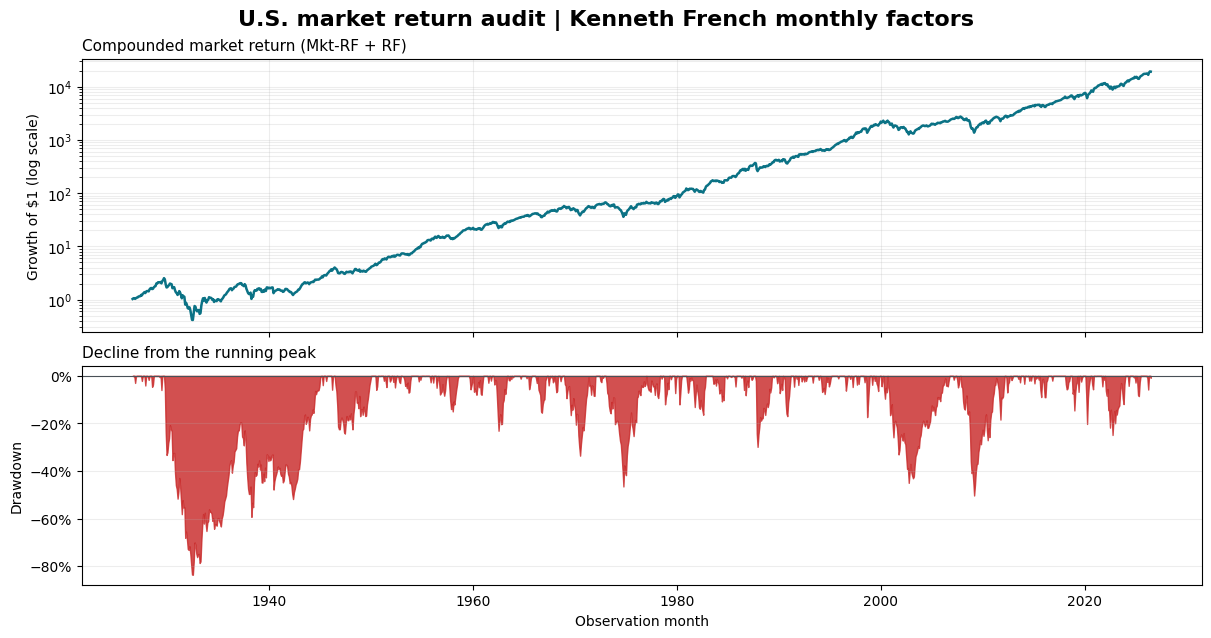

In [4]:
growth = (1.0 + market["return"]).cumprod()
drawdown = growth / growth.cummax() - 1.0

CHART_PATH.parent.mkdir(parents=True, exist_ok=True)
fig, (growth_axis, drawdown_axis) = plt.subplots(
    2,
    1,
    figsize=(12, 6.27),
    dpi=100,
    sharex=True,
    gridspec_kw={"height_ratios": [1.25, 1.0]},
    layout="constrained",
)
fig.suptitle("U.S. market return audit | Kenneth French monthly factors", fontsize=16, fontweight="bold")

growth_axis.plot(market["date"], growth, color="#0B7285", linewidth=1.8)
growth_axis.set_yscale("log")
growth_axis.set_ylabel("Growth of $1 (log scale)")
growth_axis.set_title("Compounded market return (Mkt-RF + RF)", loc="left", fontsize=11)
growth_axis.grid(True, which="both", alpha=0.22)

drawdown_axis.fill_between(market["date"], drawdown, 0, color="#C92A2A", alpha=0.82)
drawdown_axis.axhline(0, color="#495057", linewidth=0.8)
drawdown_axis.yaxis.set_major_formatter(PercentFormatter(1.0))
drawdown_axis.set_ylabel("Drawdown")
drawdown_axis.set_xlabel("Observation month")
drawdown_axis.set_title("Decline from the running peak", loc="left", fontsize=11)
drawdown_axis.grid(True, axis="y", alpha=0.22)

fig.set_facecolor("white")
fig.savefig(CHART_PATH, dpi=100, facecolor="white")
print(f"Saved {CHART_PATH.relative_to(REPO_ROOT)} ({fig.canvas.get_width_height()[0]} x {fig.canvas.get_width_height()[1]} px)")
plt.show()

## Dependence on the best months

These values come directly from the auditor's reported metrics. They show how much the compounded full-history result changes when the strongest 1, 3, or 5 monthly observations are removed.

In [5]:
original_return = metrics.total_compounded_return
sensitivity_rows = [
    {
        "Scenario": "All months",
        "Compounded return": f"{original_return:.2%}",
        "Reduction vs. full series": "0.0%",
    }
]
for removed_count in (1, 3, 5):
    scenario_return = metrics.return_without_best_periods[removed_count]
    relative_reduction = (original_return - scenario_return) / original_return
    sensitivity_rows.append(
        {
            "Scenario": f"Remove best {removed_count}",
            "Compounded return": f"{scenario_return:.2%}",
            "Reduction vs. full series": f"{relative_reduction:.1%}",
        }
    )
display(pd.DataFrame(sensitivity_rows).set_index("Scenario"))

,Compounded return,Reduction vs. full series
Scenario,,
All months,1922351.49%,0.0%
Remove best 1,1383854.71%,28.0%
Remove best 3,755030.65%,60.7%
Remove best 5,501684.01%,73.9%


## Controlled corruption check

The next cell creates an **intentionally corrupted temporary copy** of the real two-column input. It inserts one duplicate date, swaps one adjacent pair to create an out-of-order observation, and replaces one return with invalid text. The original downloaded data remains unchanged.

In [6]:
corrupted_records = audit_input.to_dict(orient="records")
duplicate_date = corrupted_records[24]["date"]
corrupted_records.insert(25, corrupted_records[24].copy())
corrupted_records[101], corrupted_records[102] = (
    corrupted_records[102],
    corrupted_records[101],
)
out_of_order_date = corrupted_records[102]["date"]
invalid_date = corrupted_records[70]["date"]
corrupted_records[70]["return"] = "not-a-number"
corrupted_input = pd.DataFrame(corrupted_records)

with TemporaryDirectory(prefix="return-audit-corrupted-") as temporary_directory:
    corrupted_path = Path(temporary_directory) / "intentionally_corrupted_returns.csv"
    corrupted_input.to_csv(corrupted_path, index=False)
    corrupted_report = audit_file(corrupted_path)

expected_failures = {"duplicate_dates", "date_order", "unparseable_values"}
detected_failures = {
    finding.code
    for finding in corrupted_report.findings
    if finding.status.value == "FAIL"
}
if not expected_failures.issubset(detected_failures):
    raise AssertionError(f"Expected {expected_failures}, detected {detected_failures}.")

print("INTENTIONALLY CORRUPTED TEMPORARY COPY")
print(f"Duplicate date inserted: {duplicate_date}")
print(f"Out-of-order observation: {out_of_order_date}")
print(f"Invalid return inserted at: {invalid_date}")
print(f"Audit result: {corrupted_report.summary_status.value} (exit code {corrupted_report.exit_code()})")
display(
    pd.DataFrame(
        [
            {
                "Status": finding.status.value,
                "Check": finding.title,
                "Explanation": finding.explanation,
            }
            for finding in corrupted_report.findings
            if finding.code in expected_failures
        ]
    )
)

INTENTIONALLY CORRUPTED TEMPORARY COPY
Duplicate date inserted: 1928-07-31
Out-of-order observation: 1934-11-30
Invalid return inserted at: 1932-04-30
Audit result: FAIL (exit code 1)


,Status,Check,Explanation
0,FAIL,Unparseable values,unparseable return value(s) on row(s) 72.
1,FAIL,Duplicate dates,Found 1 duplicate row(s) for date(s): 1928-07-31. Only the first occurrence of each date is analyzed.
2,FAIL,Date order,Dates move backwards 1 time(s) in file order. Metrics use chronological order.


## Interpretation and limitations

The full-history audit separates basic data integrity from statistical characteristics: a structurally clean series can still experience severe drawdowns and can depend materially on a small number of strong months. The controlled copy confirms that duplicate dates, incorrect ordering, and invalid values are surfaced explicitly rather than hidden in a combined score.

This is a **real, revisable research dataset**, and its construction methodology has changed over time. The reconstructed broad-market benchmark is not an investable strategy and does not include implementation costs, taxes, or investor-specific constraints. The auditor cannot detect look-ahead bias, prove that any strategy is valid, or predict future returns. This notebook is educational, is not investment advice, and makes no recommendation to buy or sell any asset.